<center>
  <img src="https://drive.google.com/uc?id=10HRuz2cSNNqadaY5wblF-b-vNTZWLv4g" width="500" />
</center>

#Tour por Europa
##Descripción del problema:
 A la agencia, Explorer, llego un grupo de universitarios quienes comentaron que contaban con un buen presupuesto económico pero no contaban con mucho tiempo para realizar sus vacaciones dada el corto intervalo de tiempo que les dio la Universidad, también, comentaron que sus planes eran recorrer Europa en tren visitando las capitales de los paises más grandes del mapa y lo ideal era que se les proporcionara el recorrido ferreo con menor duración posible, en horas y de manera muy eficaz para disfrutar mejor de los destinos.

##Modelo de grafos:
Para el desarrollo de una solución al problema propuesto fue necesario la implementación de una matriz de pesos propia de la teoria de grafos dirigidos y no dirigidos, encargada de señalar la existencia de aristas entre los distintos nodos del grafo, señalando que las ponderaciones del grafo se trabajarán en tiempo, especificamente en horas. Por otro lado, para la representación grafica del grafo fue utilizado la librería  Matplotlib del lenguaje PYTHON la cual permite mostrar los resultados de la implementación.

##Algoritmo candidato para la solución:
En esta solución fue implementado el algoritmo de Kruskal, este es un algoritmo utilizado sobre grafos no dirigidos y ponderados cuya función es encontrar el Árbol Recubridor Mínimo (ARM), el cual consiste en un árbol que conecte a todos los nodos del grafo sin generar ningún bucle; se decidió emplearlo ya que es el que más se adaptaba a las condiciones descritas en el apartado anterior escogiendo los trayectos con menor duración. La lógica de este algoritmo ira de la mano con la antes mencionada matriz de pesos, pues sobre ella se evaluaran y escogerán aquellas aristas de menor ponderación.



###📚***IMPORTACION DE LIBRERIAS***📚

In [ ]:
#IMPORTANTE EJECUTAR ANTES DE USAR LAS DEMAS CELDAS
import networkx as nx
import matplotlib.pyplot as plt

###⚙️***CLASE DE MATRIZ DE PESOS***⚙️

In [ ]:
class MatrizPesos:
    def __init__(self, nodos): #Constructor de una matriz de pesos
        self.V = nodos    #Numero de vertices
        self.A = 0        #Numero de aristas
        self.matrizPesos = [[0] * nodos for _ in range(nodos)]   #Matriz de ponderaciones
    def getV(self):
        return self.V

    def getA(self):
        return self.A

    def getMatrizPesos(self):
        return self.matrizPesos

    def enlazarNodosConPeso(self, ni, nf, peso):    #Metodo que crea una arista entre dos nodos con su peso
        self.matrizPesos[ni][nf] = peso
        self.matrizPesos[nf][ni] = peso
        self.A += 1

    def imprimirMatriz(self):   #Metodo para imprimir la matriz
        for i in range(self.V):
            print(f"{i}: ", end="")
            for j in range(self.V):
                print(f"{self.matrizPesos[i][j]} ", end="")
            print("")

    def completarPesos(self):      #Metodo para completar pesos, es decir, no dejar en 0 aquellos nodos que no se relacionan sino en -1.
        for i in range(self.V):
            for j in range(self.V):
                if self.matrizPesos[i][j] == 0 and j != i:
                    self.matrizPesos[i][j] = -1

###⚙️***CLASE CON EL MÉTODO DE KRUSKAL***⚙️

In [ ]:
class AlgKruskal:
    def __init__(self, matriz, verti):   # Constructor del algoritmo de kruskal
        self.pesoMin = 0         # Peso total mínimo del ARM
        self.vectolDestinos = [0] * verti    # Vector que contendrá los nodos destino ya recorridos
        self.Matriz = matriz     # Matriz de pesos del grafo
        self.vertices = verti     # Número de vertices del grafo

    def arbolRecubridorMin(self):  # Método del algoritmo que encuentra el ARM
        Grafo2 = nx.Graph()  # Creación del gráfico en un plano cartesiano

        pos = {"Belgica": (0, 2), "Paises B": (0, 5), "UK": (-3.5, 2), "Irlanda": (-4, 5),
               "Francia": (-3, -1), "España": (-2.5, -4), "Portugal": (-6, -4), "Italia": (0.5, -4),
               "Suiza":(0.5,-1), "Noruega":(3,4.3), "Alemania":(4.5,1.5), "Rep Ch":(4,-1),
               "Croacia":(4,-4), "Suecia":(6,5), "Finlandia":(10,5), "Polonia":(8.5,2), "Rumania":(7.5,-0.5),
               "Macedonia":(7.4,-2.5), "Grecia":(10,-4)}  # Posiciones en el plano de los nodos

        opciones = {   # Detalles de edición para las fuentes
            "font_size": 9,
            "node_size": 2100,
            "node_color": "white",
            "edgecolors": "black",
            "linewidths": 1,
            "width": 1,
        }

        a = 100  # Entero que ayudará a establecer la arista con menor peso en el grafo
        c = 0   # Entero que ayudará a saber cuántas veces se repite el proceso del algoritmo
        pro = 0
        dest = 0  # Enteros que me indican la procedencia y destino de la arista escogida
        print("Bienvenido, este es su recorrido:")
        while c < self.vertices - 1:    # Condición que finaliza el algoritmo cuando el árbol recubridor mínimo tenga "v-1" aristas siendo "v" el número de nodos
            for i in range(self.vertices):
                for j in range(self.vertices):
                    if self.Matriz[i][j] > 0 and self.Matriz[i][j] < a:   # Busco la arista de menor peso en todo el grafo
                        a = self.Matriz[i][j]    # Guardo su ponderación, nodo destino y origen
                        pro = i
                        dest = j
            if self.Verificar(dest):   # Verifico si el nodo que es destino ya fue recorrido antes
                if not self.Verificar(pro):  # Ahora verifico si el nodo origen de la arista también fue recorrido antes, de esta manera se evitan los ciclos
                    self.vectolDestinos[c] = pro   # Añado el nodo origen al vector de destinos en caso de que no esté
                    self.Matriz[pro][dest] = 0  # "Elimino" esa arista pues ya sé que es la de menor peso, no la necesito más; tengo guardado sus nodos y peso
                    self.Matriz[dest][pro] = 0
                    c += 1  # Aumento el número de aristas del ARM
                    self.pesoMin += a  # Sumo el peso de la arista al peso del ARM
                    Grafo2.add_edge(dc[pro], dc[dest], weight=a)  # Agrego los nodos, arista y peso al nuevo grafo que representará la solución del problema
                    a = 100  # Inicializo otra vez en 100 para repetir el proceso de búsqueda
                else:    # Si salto a este condicional quiere decir que la arista seleccionada me generaba un ciclo
                    self.Matriz[pro][dest] = 0  # Elimino la arista
                    self.Matriz[dest][pro] = 0
                    a = 100  # Inicializo otra vez en 100 para repetir el proceso de búsqueda
            else:
                self.vectolDestinos[c] = dest   # Como el nodo destino no se encontraba entre los nodos ya recorridos, lo agrego
                self.Matriz[pro][dest] = 0   # "Elimino" esa arista pues ya sé que es la de menor peso, no la necesito más; tengo guardado sus nodos y peso
                self.Matriz[dest][pro] = 0
                c += 1  # Aumento el número de aristas del ARM
                self.pesoMin += a   # Sumo el peso de la arista al peso del ARM
                Grafo2.add_edge(dc[pro], dc[dest], weight=a)  # Agrego los nodos, arista y peso al nuevo grafo que representará la solución del problema
                a = 100  # Inicializo otra vez en 100 para repetir el proceso de búsqueda
        print("")
        print("La duración total aproximada de la ruta es de " + str(self.pesoMin) + " horas")
        nx.draw_networkx(Grafo2, pos, **opciones)    # Métodos de la librería networkX para imprimir el grafo en pantalla
        labels = nx.get_edge_attributes(Grafo2, 'weight')
        nx.draw_networkx_edge_labels(Grafo2, pos, edge_labels=labels)
        plt.title("Ruta optimizada a tomar")
        plt.show()

    def Verificar(self, destino):  # Método que me permite verificar si un nodo ya fue destino antes
        for i in range(len(self.vectolDestinos)):
            if destino == self.vectolDestinos[i]:
                return True
        return False

###⚙️***EJECUCIOÓN DEL PROGRAMA PRINCIPAL***⚙️

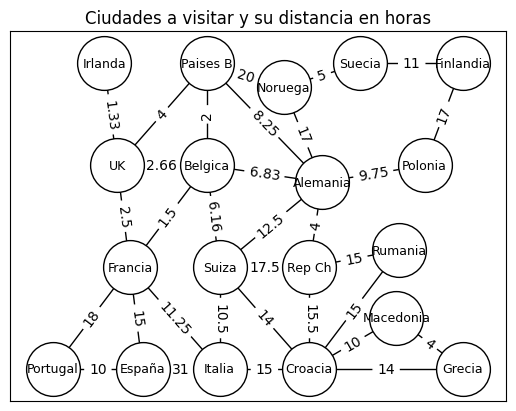

In [ ]:
#Grafica del grafo "mapa" original
Grafo = nx.Graph()
Grafo.add_edge("Belgica", "Paises B",weight=2)
Grafo.add_edge("Belgica", "UK",weight=2.66)
Grafo.add_edge("Belgica", "Francia",weight=1.5)
Grafo.add_edge("Belgica", "Suiza",weight=6.16)
Grafo.add_edge("Belgica", "Alemania",weight=6.83)
Grafo.add_edge("UK", "Irlanda",weight=1.33)
Grafo.add_edge("UK", "Francia",weight=2.5)
Grafo.add_edge("UK", "Paises B",weight=4)
Grafo.add_edge("Francia", "Portugal",weight=18)
Grafo.add_edge("Francia", "España",weight=15)
Grafo.add_edge("Francia", "Italia",weight=11.25)
Grafo.add_edge("Portugal", "España",weight=10)
Grafo.add_edge("España", "Italia",weight=31)
Grafo.add_edge("Suiza", "Italia",weight=10.5)
Grafo.add_edge("Suiza", "Alemania",weight=12.5)
Grafo.add_edge("Suiza", "Rep Ch",weight=17.5)
Grafo.add_edge("Suiza", "Croacia",weight=14)
Grafo.add_edge("Paises B", "Noruega",weight=20)
Grafo.add_edge("Paises B", "Alemania",weight=8.25)
Grafo.add_edge("Italia", "Croacia",weight=15)
Grafo.add_edge("Noruega", "Suecia",weight=5)
Grafo.add_edge("Noruega", "Alemania",weight=17)
Grafo.add_edge("Alemania", "Polonia",weight=9.75)
Grafo.add_edge("Alemania", "Rep Ch",weight=4)
Grafo.add_edge("Suecia", "Finlandia",weight=11)
Grafo.add_edge("Finlandia", "Polonia",weight=17)
Grafo.add_edge("Rep Ch", "Rumania",weight=15)
Grafo.add_edge("Rep Ch", "Croacia",weight=15.5)
Grafo.add_edge("Croacia", "Rumania",weight=15)
Grafo.add_edge("Croacia", "Macedonia",weight=10)
Grafo.add_edge("Croacia", "Grecia",weight=14)
Grafo.add_edge("Grecia", "Macedonia",weight=4)

pos = {"Belgica": (0, 2), "Paises B": (0, 5), "UK": (-3.5, 2), "Irlanda": (-4, 5),
       "Francia": (-3, -1), "España": (-2.5, -4), "Portugal": (-6, -4),
       "Italia": (0.5, -4), "Suiza":(0.5,-1), "Noruega":(3,4.3), "Alemania":(4.5,1.5), "Rep Ch":(4,-1),
        "Croacia":(4,-4), "Suecia":(6,5), "Finlandia":(10,5), "Polonia":(8.5,2), "Rumania":(7.5,-0.5),
        "Macedonia":(7.4,-2.5), "Grecia":(10,-4)}  #Posiciones en el plano de los nodos

opciones = {   #Detalles de edicion para las fuentes
    "font_size": 9,
    "node_size": 1500,
    "node_color": "white",
    "edgecolors": "black",
    "linewidths": 1,
    "width": 1,
}
nx.draw_networkx(Grafo, pos, **opciones)   #Metodos de la libreria networkX para imprimir el grafo en pantalla
labels = nx.get_edge_attributes(Grafo, 'weight')
nx.draw_networkx_edge_labels(Grafo, pos, edge_labels=labels)
plt.title("Ciudades a visitar y su distancia en horas")
plt.show()
print("")

###⚙️***CREACIÓN DE LA MATRIZ DE PESOS Y EJECUCIÓN DEL ALGORITMO***⚙️

Ahora, a partir del anterior grafo que representa la distancia en horas en tren entre las capitales de los países europeos se usará el algoritmo de Kruskal para encontrar el ARM


Bienvenido, este es su recorrido:

La duración total aproximada de la ruta es de 145.57 horas


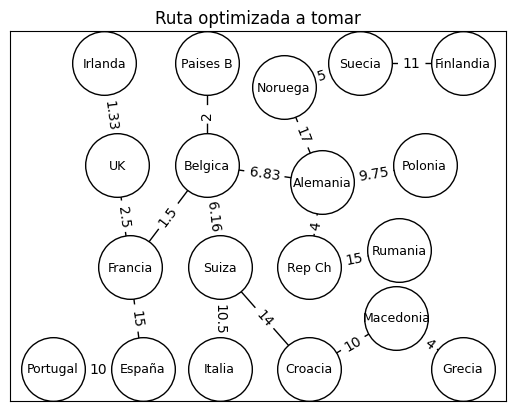

In [ ]:
#Creacion del grafo para luego efectuar el algoritmo
matriz = MatrizPesos(19)  #Creacion de la matriz de pesos con el numero de nodos (ciudades) ya conocido
dc = {0:"Belgica",1:"Paises B",2:"UK",3:"Irlanda",4:"Francia",
      5:"España",6:"Portugal",7:"Italia",8:"Suiza",9:"Noruega",
      10:"Alemania",11:"Rep Ch",12:"Croacia",13:"Suecia",
      14:"Finlandia",15:"Polonia",16:"Rumania",17:"Macedonia",
      18:"Grecia"} #Diccionario que relaciona un entero con una ciudad para facilitar el proceso del algoritmo de kruskal
#Se relacionan los nodos y sus pesos
matriz.enlazarNodosConPeso(0,1,2)
matriz.enlazarNodosConPeso(0,2,2.66)
matriz.enlazarNodosConPeso(0,4,1.5)
matriz.enlazarNodosConPeso(0,8,6.16)
matriz.enlazarNodosConPeso(0,10,6.83)
matriz.enlazarNodosConPeso(1,2,4)
matriz.enlazarNodosConPeso(1,10,8.25)
matriz.enlazarNodosConPeso(1,9,20)
matriz.enlazarNodosConPeso(2,3,1.33)
matriz.enlazarNodosConPeso(2,4,2.5)
matriz.enlazarNodosConPeso(4,6,18)
matriz.enlazarNodosConPeso(4,5,15)
matriz.enlazarNodosConPeso(4,7,11.25)
matriz.enlazarNodosConPeso(5,6,10)
matriz.enlazarNodosConPeso(5,7,31)
matriz.enlazarNodosConPeso(7,8,10.5)
matriz.enlazarNodosConPeso(7,12,15)
matriz.enlazarNodosConPeso(8,10,12.5)
matriz.enlazarNodosConPeso(8,11,17.5)
matriz.enlazarNodosConPeso(8,12,14)
matriz.enlazarNodosConPeso(9,13,5)
matriz.enlazarNodosConPeso(9,10,17)
matriz.enlazarNodosConPeso(10,15,9.75)
matriz.enlazarNodosConPeso(10,11,4)
matriz.enlazarNodosConPeso(11,16,15)
matriz.enlazarNodosConPeso(11,12,15.5)
matriz.enlazarNodosConPeso(12,16,15)
matriz.enlazarNodosConPeso(12,17,10)
matriz.enlazarNodosConPeso(12,18,14)
matriz.enlazarNodosConPeso(13,14,11)
matriz.enlazarNodosConPeso(14,15,17)
matriz.enlazarNodosConPeso(17,18,4)
Algoritmo = AlgKruskal(matriz.matrizPesos,matriz.V)  #Creacion de un Kruskal para el grafo desarrollado
print("")
Algoritmo.arbolRecubridorMin()    #Inicio del proceso de busqueda del ARM
print("")

##Resultados Obtenidos 📌
Una vez que encontramos el arbol recubridor mínimo del grafo proporcionado incialmente (la duracón del viaje ferreo entre las ciudades más grandes del mapa de Europa), podemos decir que este es el recorrido ferreo, que en términos de horas, dura menos; por lo tanto, es ideal para que este grupo de estudiantes logre recorrer la mayor parte del continente europeo disfrutando de su estadia en las ciudades y gastando el menor tiempo posible en el desplazamiento entre ellas.